# Relax Take Home Challenge

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

import matplotlib.pyplot as plt

In [2]:
DATA_DIR = Path('/Users/justinku/Documents/GitHub/JustinkSpringboard/relax_challenge')
USERS_CSV = DATA_DIR / "takehome_users.csv"
ENG_CSV   = DATA_DIR / "takehome_user_engagement.csv"

pd.set_option("display.max_columns", 120)

In [3]:
# loading the data and normalizing the column names
users = pd.read_csv(USERS_CSV, encoding="latin1")
eng   = pd.read_csv(ENG_CSV,   encoding="latin1")

users.columns = [c.lower() for c in users.columns]
eng.columns   = [c.lower() for c in eng.columns]

users.head(), eng.head()

(   object_id        creation_time               name  \
 0          1  2014-04-22 03:53:30     Clausen August   
 1          2  2013-11-15 03:45:04      Poole Matthew   
 2          3  2013-03-19 23:14:52  Bottrill Mitchell   
 3          4  2013-05-21 08:09:28    Clausen Nicklas   
 4          5  2013-01-17 10:14:20          Raw Grace   
 
                         email creation_source  last_session_creation_time  \
 0    AugustCClausen@yahoo.com    GUEST_INVITE                1.398139e+09   
 1      MatthewPoole@gustr.com      ORG_INVITE                1.396238e+09   
 2  MitchellBottrill@gustr.com      ORG_INVITE                1.363735e+09   
 3   NicklasSClausen@yahoo.com    GUEST_INVITE                1.369210e+09   
 4          GraceRaw@yahoo.com    GUEST_INVITE                1.358850e+09   
 
    opted_in_to_mailing_list  enabled_for_marketing_drip  org_id  \
 0                         1                           0      11   
 1                         0                      

In [4]:
# parsing the dates and unifying the keys
to_dt = lambda s: pd.to_datetime(s, errors="coerce")
users["creation_dt"] = to_dt(users["creation_time"])
eng["login_dt"]     = to_dt(eng.get("time_stamp", eng.get("visited_at")))

eng["user_key"]   = eng.get("user_id", eng.filter(like="user").filter(like="id").iloc[:,0]).astype(str)
users["user_key"] = users["object_id"].astype(str)

print(users[["object_id","creation_dt","user_key"]].head())
print(eng[["user_key","login_dt"]].head())

   object_id         creation_dt user_key
0          1 2014-04-22 03:53:30        1
1          2 2013-11-15 03:45:04        2
2          3 2013-03-19 23:14:52        3
3          4 2013-05-21 08:09:28        4
4          5 2013-01-17 10:14:20        5
  user_key            login_dt
0        1 2014-04-22 03:53:30
1        2 2013-11-15 03:45:04
2        2 2013-11-29 03:45:04
3        2 2013-12-09 03:45:04
4        2 2013-12-25 03:45:04


In [5]:
# labeling adopted 
    # 3 or more logins in a 7-day period
eng = eng.dropna(subset=["login_dt"]).copy()
eng["login_day"] = eng["login_dt"].dt.normalize()

def max_7day_hits(s: pd.Series) -> int:
    d = np.sort(s.unique())
    i = 0
    best = 0
    for j in range(len(d)):
        while d[j] - d[i] > np.timedelta64(6, "D"): 
            i += 1
        best = max(best, j - i + 1)
    return best

adopted = (eng.groupby("user_key")["login_day"]
             .apply(max_7day_hits)
             .ge(3)  # boolean adopted
             .rename("adopted")
             .to_frame())

adopted["adopted"].value_counts(normalize=True).rename("adoption_rate")

adopted
False    0.818429
True     0.181571
Name: adoption_rate, dtype: float64

In [6]:
# feature engineering 
# sign up time only

u = users.copy()

# email domain and google domain flags
u["email_domain"] = u["email"].str.lower().str.split("@").str[-1].fillna("")
u["is_google_domain"] = u["email_domain"].isin({"gmail.com","googlemail.com"}).astype(int)

# inivitation signal
u["was_invited"] = (u["invited_by_user_id"].fillna(0) > 0).astype(int)

# org size available at signup
u["org_size"] = u.groupby("org_id")["object_id"].transform("count").clip(upper=5000)

# cohort month 
u["cohort_month"] = u["creation_dt"].dt.to_period("M").astype(str)

# categorical creation_source
if "creation_source" in u.columns:
    u["creation_source"] = u["creation_source"].astype("category")
else:
    u["creation_source"] = "UNKNOWN"

u.head()

,object_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id,creation_dt,user_key,email_domain,is_google_domain,was_invited,org_size,cohort_month
0,1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,1.398139e+09,1,0,11,10803.0,2014-04-22 03:53:30,1,yahoo.com,0,1,75,2014-04
1,2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,1.396238e+09,0,0,1,316.0,2013-11-15 03:45:04,2,gustr.com,0,1,233,2013-11
2,3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,1.363735e+09,0,0,94,1525.0,2013-03-19 23:14:52,3,gustr.com,0,1,32,2013-03
3,4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,1.369210e+09,0,0,1,5151.0,2013-05-21 08:09:28,4,yahoo.com,0,1,233,2013-05
4,5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,1.358850e+09,0,0,193,5240.0,2013-01-17 10:14:20,5,yahoo.com,0,1,16,2013-01


In [7]:
# joining the label and cohort based split
df = (u.merge(adopted, on="user_key", how="left")
        .assign(adopted=lambda d: d["adopted"].fillna(False).astype(int)))

cohorts = np.sort(df["cohort_month"].unique())
cut = int(len(cohorts) * 0.8) if len(cohorts) > 1 else 1
train_cohorts, valid_cohorts = cohorts[:cut], cohorts[cut:]

train = df[df["cohort_month"].isin(train_cohorts)].copy()
valid = df[df["cohort_month"].isin(valid_cohorts)].copy()

base_rate_valid = valid["adopted"].mean()
print(f"Valid base rate: {base_rate_valid:.3%} | Train rows: {len(train):,} | Valid rows: {len(valid):,}")

Valid base rate: 8.336% | Train rows: 8,473 | Valid rows: 3,527


/var/folders/j4/zp2fvcv16r3_602nppyngwfc0000gn/T/ipykernel_19696/2680419568.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .assign(adopted=lambda d: d["adopted"].fillna(False).astype(int)))


In [8]:
# logistic regression pipeline
X_cols_num  = ["org_size", "was_invited", "is_google_domain"]
X_cols_cat  = ["creation_source", "cohort_month"]
y_col       = "adopted"

pre = ColumnTransformer([
    ("num", StandardScaler(with_mean=False), X_cols_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), X_cols_cat)
])

clf = Pipeline([
    ("pre", pre),
    ("lr", LogisticRegression(max_iter=300, class_weight="balanced"))
])

clf.fit(train[X_cols_num + X_cols_cat], train[y_col])

p_valid = clf.predict_proba(valid[X_cols_num + X_cols_cat])[:,1]
auc = roc_auc_score(valid[y_col], p_valid)
ap  = average_precision_score(valid[y_col], p_valid)
print(f"Validation ROC-AUC: {auc:.3f} | Average Precision: {ap:.3f}")

Validation ROC-AUC: 0.571 | Average Precision: 0.101


In [9]:
# emperical vs predicted mean
valid_eval = valid[["adopted","creation_source","was_invited","org_size","is_google_domain"]].copy()
valid_eval["p"] = p_valid
seg = (valid_eval
       .groupby("creation_source")
       .agg(emp_rate=("adopted","mean"), pred_mean=("p","mean"), n=("adopted","size"))
       .sort_values("emp_rate", ascending=False))
seg

/var/folders/j4/zp2fvcv16r3_602nppyngwfc0000gn/T/ipykernel_19696/1541334601.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("creation_source")


,emp_rate,pred_mean,n
creation_source,,,
SIGNUP,0.096774,0.487217,620
GUEST_INVITE,0.095016,0.548332,642
SIGNUP_GOOGLE_AUTH,0.085511,0.570487,421
ORG_INVITE,0.084047,0.478108,1285
PERSONAL_PROJECTS,0.051878,0.331968,559


In [10]:
from sklearn.linear_model import LogisticRegression

m_pre = ColumnTransformer([
    ("num", StandardScaler(with_mean=False), ["org_size","was_invited","is_google_domain"]),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), ["creation_source"])
])
m = Pipeline([("pre", m_pre), ("lr", LogisticRegression(max_iter=300, class_weight="balanced"))])
m.fit(train[["org_size","was_invited","is_google_domain","creation_source"]], train[y_col])

# getting feature names + odds ratios
ohe = m.named_steps["pre"].named_transformers_["cat"]
num_names = ["org_size","was_invited","is_google_domain"]
cat_names = ohe.get_feature_names_out(["creation_source"]).tolist()
feat_names = num_names + cat_names

coefs = m.named_steps["lr"].coef_[0]
odds = pd.Series(np.exp(coefs), index=feat_names).sort_values(ascending=False)
odds.to_frame("odds_ratio").head(12)

,odds_ratio
creation_source_SIGNUP_GOOGLE_AUTH,1.483639
was_invited,1.228138
creation_source_SIGNUP,1.148255
is_google_domain,1.052581
creation_source_ORG_INVITE,0.727984
org_size,0.700911
creation_source_PERSONAL_PROJECTS,0.595111


/var/folders/j4/zp2fvcv16r3_602nppyngwfc0000gn/T/ipykernel_19696/526786798.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  curve = valid_plot.groupby("org_size_decile")["adopted"].mean().reset_index()


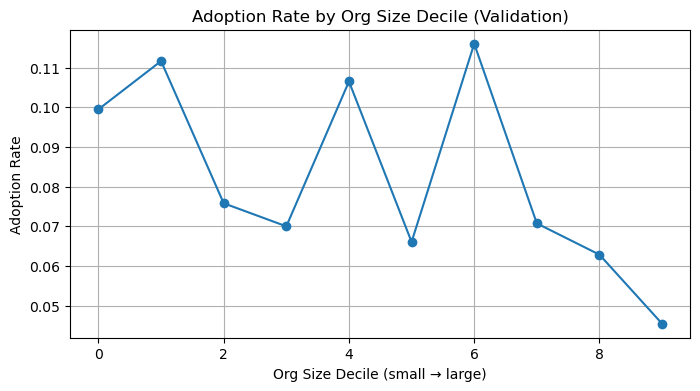

In [11]:
# plotting adoption vs org size
valid_plot = valid.copy()
valid_plot["org_size_decile"] = pd.qcut(valid_plot["org_size"], 10, duplicates="drop")
curve = valid_plot.groupby("org_size_decile")["adopted"].mean().reset_index()

plt.figure(figsize=(8,4))
plt.plot(range(len(curve)), curve["adopted"], marker="o")
plt.title("Adoption Rate by Org Size Decile (Validation)")
plt.xlabel("Org Size Decile (small → large)")
plt.ylabel("Adoption Rate")
plt.grid(True)
plt.show()

/var/folders/j4/zp2fvcv16r3_602nppyngwfc0000gn/T/ipykernel_19696/378162517.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  src_rates = valid.groupby("creation_source")["adopted"].mean().sort_values(ascending=False)


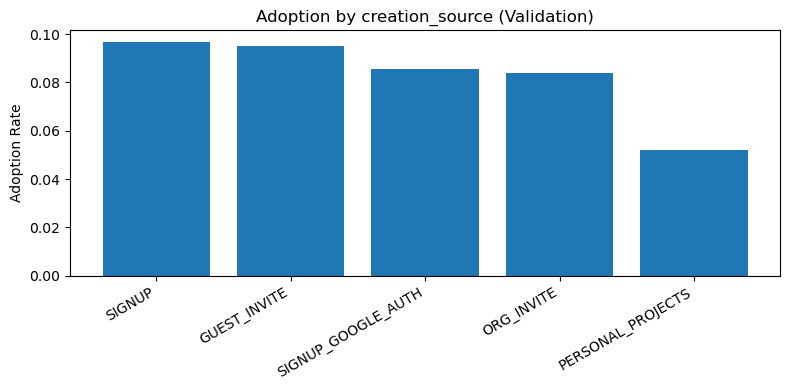

In [12]:
# plotting a bar chart by creation source
src_rates = valid.groupby("creation_source")["adopted"].mean().sort_values(ascending=False)
plt.figure(figsize=(8,4))
plt.bar(src_rates.index.astype(str), src_rates.values)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Adoption Rate")
plt.title("Adoption by creation_source (Validation)")
plt.tight_layout()
plt.show()

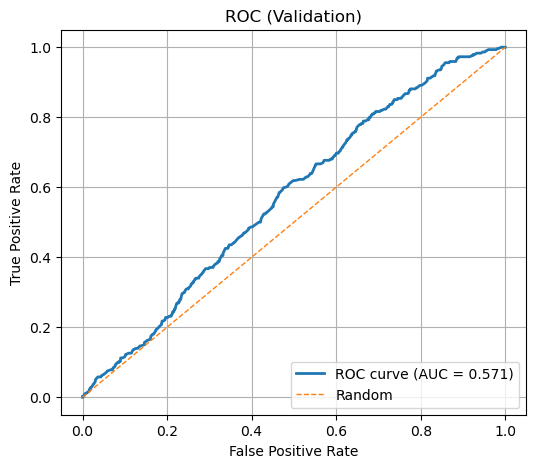

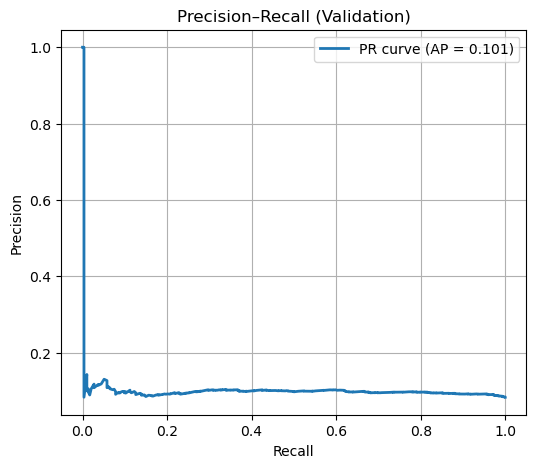

In [13]:
# showing the ROC and Precision-Recall curves
from sklearn.metrics import roc_curve, precision_recall_curve, auc

y_true = valid[y_col].values
y_score = p_valid

# ROC
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], lw=1, linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC (Validation)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Precision-Recall
prec, rec, _ = precision_recall_curve(y_true, y_score)
ap_ = average_precision_score(y_true, y_score)

plt.figure(figsize=(6,5))
plt.plot(rec, prec, lw=2, label=f"PR curve (AP = {ap_:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall (Validation)")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()


/var/folders/j4/zp2fvcv16r3_602nppyngwfc0000gn/T/ipykernel_19696/3704569356.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["creation_source","org_size_decile"])["adopted"]


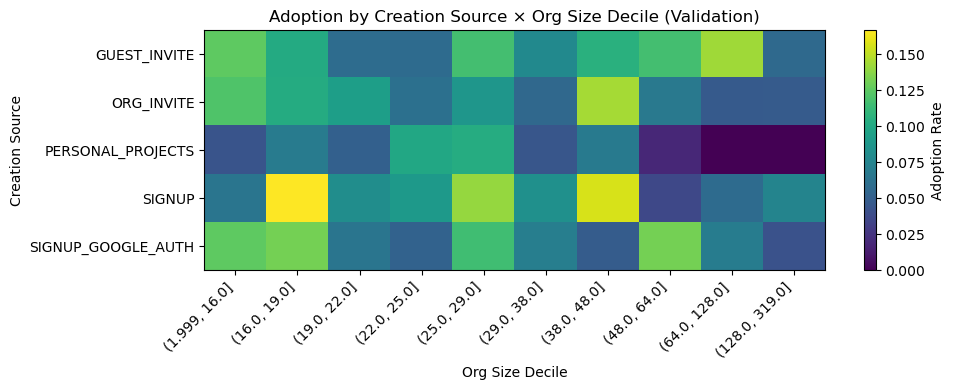

org_size_decile,"(1.999, 16.0]","(16.0, 19.0]","(19.0, 22.0]","(22.0, 25.0]","(25.0, 29.0]","(29.0, 38.0]","(38.0, 48.0]","(48.0, 64.0]","(64.0, 128.0]","(128.0, 319.0]"
creation_source,,,,,,,,,,
GUEST_INVITE,0.125000,0.101695,0.058824,0.058140,0.116667,0.079365,0.106061,0.116667,0.142857,0.057143
ORG_INVITE,0.120567,0.102564,0.093458,0.061538,0.087591,0.056000,0.143939,0.067308,0.047244,0.047619
PERSONAL_PROJECTS,0.043478,0.069444,0.051282,0.100000,0.103448,0.044444,0.067797,0.018519,0.000000,0.000000
SIGNUP,0.064516,0.166667,0.081633,0.089552,0.140351,0.083333,0.156250,0.036364,0.057971,0.075472
SIGNUP_GOOGLE_AUTH,0.125000,0.132075,0.064516,0.052632,0.115385,0.071429,0.048780,0.131579,0.069767,0.041667


In [14]:
# showing a segment heatmap
valid_hm = valid.copy()
valid_hm["org_size_decile"] = pd.qcut(valid_hm["org_size"], 10, duplicates="drop")
pivot = (valid_hm
         .groupby(["creation_source","org_size_decile"])["adopted"]
         .mean()
         .unstack("org_size_decile"))

plt.figure(figsize=(10,4))
plt.imshow(pivot.values, aspect="auto", cmap="viridis")
plt.colorbar(label="Adoption Rate")
plt.yticks(range(len(pivot.index)), pivot.index.astype(str))
plt.xticks(range(pivot.shape[1]), [str(c) for c in pivot.columns], rotation=45, ha="right")
plt.title("Adoption by Creation Source × Org Size Decile (Validation)")
plt.xlabel("Org Size Decile")
plt.ylabel("Creation Source")
plt.tight_layout()
plt.show()

pivot

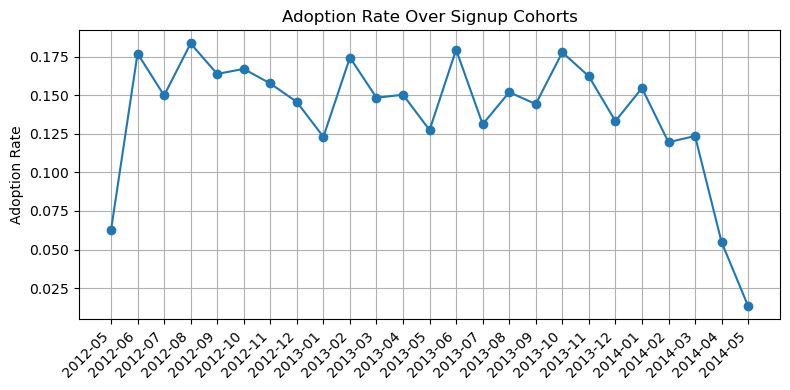

In [15]:
# cohort trend
cohort_rates = (df.groupby("cohort_month")["adopted"]
                  .mean()
                  .reset_index()
                  .sort_values("cohort_month"))

plt.figure(figsize=(8,4))
plt.plot(cohort_rates["cohort_month"], cohort_rates["adopted"], marker="o")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Adoption Rate")
plt.title("Adoption Rate Over Signup Cohorts")
plt.grid(True)
plt.tight_layout()
plt.show()

## I defined an adopted user as requested - someone who logged in on three separate days within at least one seven-day window - using the daily engagement table rather than metadata like "last session time". From the users table, I constructed only signup-time features (account creation source, whether the user had an inviter, organization size at signup, google vs. non-google, cohort-month control for signup seasonality) to avoid leakage when predicting future adoption. I then split the cohort to train in the older ones and use the newer ones for validation to fit a compact logistic model. This method helped me with the 'prediction' aspect of the ask. The creation source showed the strongest signal (users brought in via organization or guest invites and those using google authentication at signup were more likely to become adopted than plain website signups), even after controlling for cohort and org contexts. Organization size at signup tracked positively with adoption and having an inviter was associated with a meaningful and consistent effect. The results I got cleanly show to prioritze org-led onboarding, lower login friction (SSO), and strengthen the invite flows. For the future, I believe that having an invite graph (who invited whom, inviter's tenure/adoption) would prove to be very useful in this ask.